# 06 Bivariate Analysis

## Objective

Objective:
Perform bivariate analysis to understand how individual features
relate to the target variable `Churn`.

This step helps in:
- Comparing feature behavior across churn classes
- Identifying potentially important predictors
- Detecting class-specific patterns in numerical and categorical features
- Preparing for feature selection and modeling


## Imports


In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Report Paths

Store bivariate analysis outputs in dedicated report folders so tables and figures stay easy to find.


In [7]:
REPORTS_DIR = project_root / "reports"
BIVARIATE_FIGURES_DIR = REPORTS_DIR / "figures" / "bivariate"
BIVARIATE_TABLES_DIR = REPORTS_DIR / "tables" / "bivariate"
NUMERICAL_VS_TARGET_FIGURES_DIR = BIVARIATE_FIGURES_DIR / "numerical_vs_target"
NUMERICAL_VS_TARGET_TABLES_DIR = BIVARIATE_TABLES_DIR / "numerical_vs_target"

for path in [NUMERICAL_VS_TARGET_FIGURES_DIR, NUMERICAL_VS_TARGET_TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

{
    "numerical_vs_target_figures": NUMERICAL_VS_TARGET_FIGURES_DIR,
    "numerical_vs_target_tables": NUMERICAL_VS_TARGET_TABLES_DIR,
}


{'numerical_vs_target_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/bivariate/numerical_vs_target'),
 'numerical_vs_target_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/bivariate/numerical_vs_target')}

## Load Data and Separate Feature Types

Separate numerical and categorical features because the choice of comparison chart depends on feature type.


In [8]:
df = load_cleaned_data()

target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]

feature_groups = {
    "target_column": target_column,
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
}

feature_groups


{'target_column': 'Churn',
 'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod']}

## Numerical Features vs Target

Compare each numerical feature across churn classes to see whether churned and non-churned customers differ in their distributions.


In [9]:
numerical_vs_target_summary = (
    df.groupby(target_column)[numerical_columns]
    .agg(["mean", "median", "std"])
    .round(2)
)

numerical_vs_target_summary.to_csv(
    NUMERICAL_VS_TARGET_TABLES_DIR / "numerical_vs_target_summary.csv"
)

display(numerical_vs_target_summary)


tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

This summary table compares the numerical features across the two churn classes. It helps show whether churned customers tend to have lower or higher values than non-churned customers, and whether the spread within each class is narrow or wide. If the class-wise means or medians differ clearly, that feature may become important later in churn prediction.


/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
/var/folders/1l/ddpthpdj6j75gsq02qk0x0kc0000gn/T/ipykernel_47264/194556595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_column, y=column, ax=b

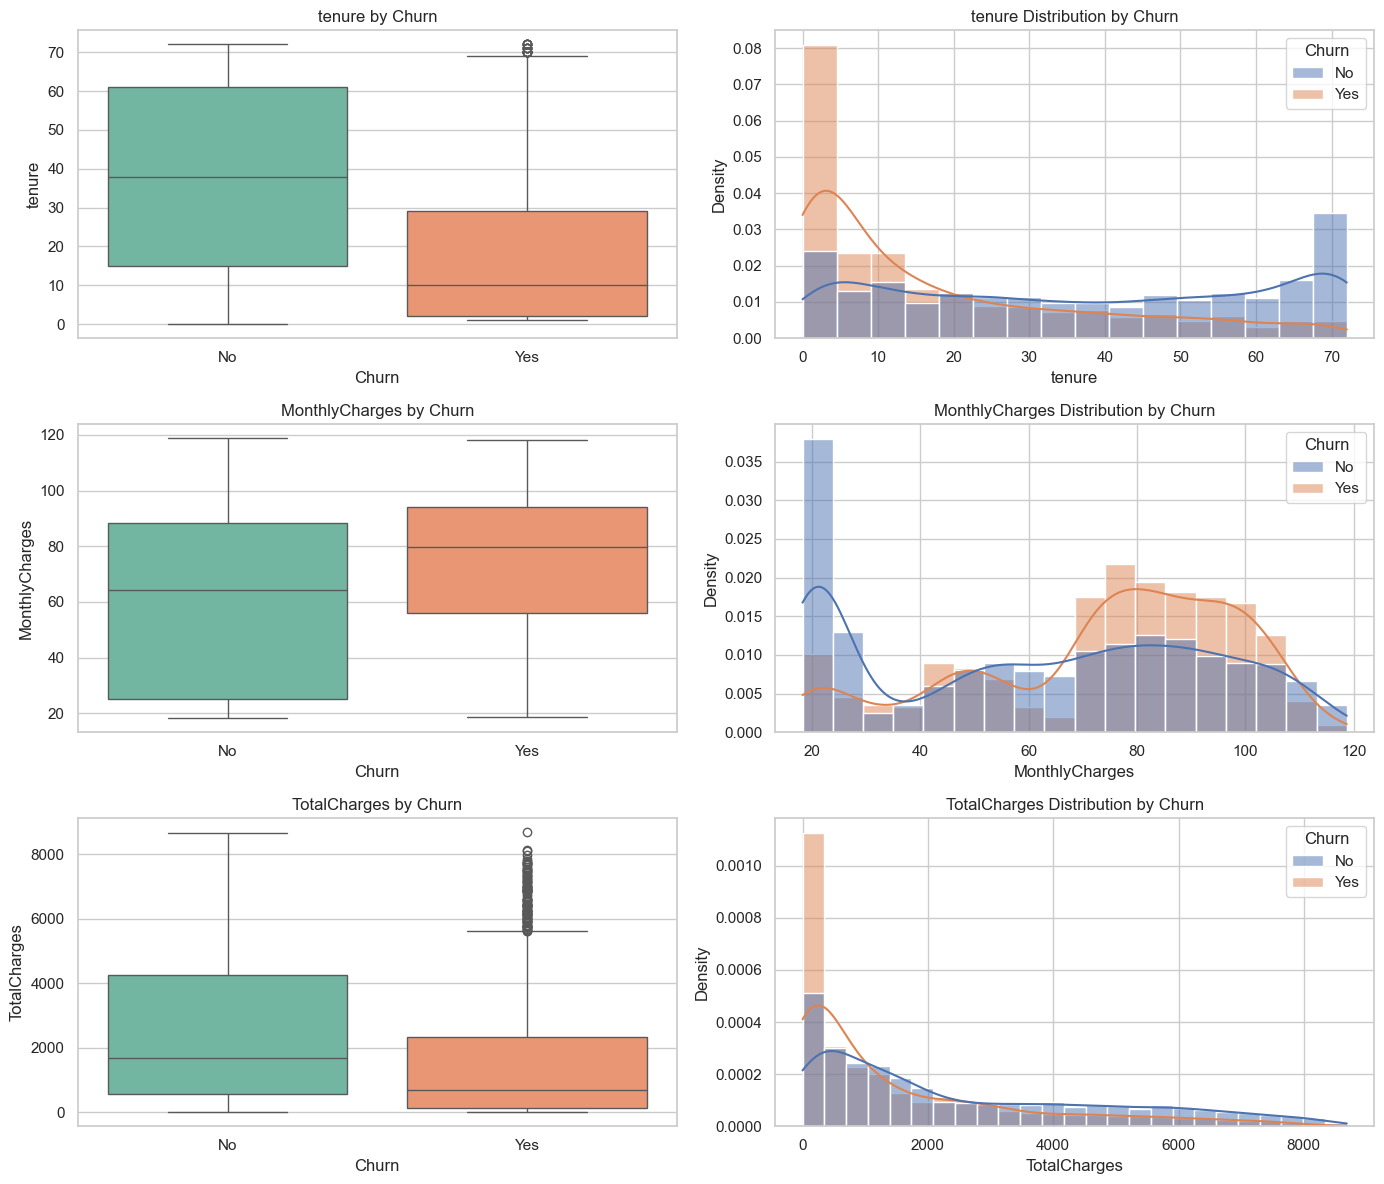

In [10]:
fig, axes = plt.subplots(len(numerical_columns), 2, figsize=(14, 4 * len(numerical_columns)))

if len(numerical_columns) == 1:
    axes = [axes]

for index, column in enumerate(numerical_columns):
    box_ax, hist_ax = axes[index]

    sns.boxplot(data=df, x=target_column, y=column, ax=box_ax, palette="Set2")
    box_ax.set_title(f"{column} by {target_column}")
    box_ax.set_xlabel(target_column)
    box_ax.set_ylabel(column)

    sns.histplot(data=df, x=column, hue=target_column, kde=True, stat="density", common_norm=False, ax=hist_ax)
    hist_ax.set_title(f"{column} Distribution by {target_column}")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig(
    NUMERICAL_VS_TARGET_FIGURES_DIR / "numerical_vs_target_distributions.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


### Numerical vs Target Insights

- Compare the medians and boxplot positions to see whether churned customers tend to have higher or lower numerical values than non-churned customers.
- `tenure` is often one of the strongest churn-related numerical features, so pay close attention to whether churned customers are concentrated at lower tenure values.
- `MonthlyCharges` and `TotalCharges` should be read together because one reflects current billing level while the other reflects longer-term accumulation over time.
- If the churn classes separate clearly in the boxplots or grouped distributions, that feature may become important later in churn analysis and modeling.
